# Computer Exercise 13.5 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.5 Sequential Quadratic Programming — *Globalization with an $\ell_1$ merit function and Armijo line search*
> **풀이 일자**: Day 50
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **2.** The pure (full-step) Lagrange–Newton SQP of Problem 1 converges only **locally**. Starting far from a
> solution, the unit step can overshoot the constraint curvature and **diverge**. Globalize the iteration with the
> $\ell_1$ **merit function**
> $$\phi_\mu(x)=f(x)+\mu\,\|c(x)\|_1$$
> and an **Armijo backtracking line search** along the SQP direction $d_k$. Choose the penalty $\mu$ so that $d_k$ is
> a descent direction for $\phi_\mu$, and compare the globalized run against the full-step run from the same far start.

### 한국어 풀이용 정리
순수 SQP(단위 스텝)는 해 근방에서만 안전하다. 먼 곳에서 출발하면 단위 스텝이 제약의 곡률을 넘겨
**발산**하거나 메리트가 **증가**할 수 있다. 목적과 제약위반을 한 척도로 묶은 $\ell_1$ **메리트 함수**
$\phi_\mu(x)=f(x)+\mu\|c(x)\|_1$ 에 대해 **Armijo 후퇴 직선탐색**으로 스텝길이 $\alpha_k$ 를 정해 전역화한다.
$d_k$ 가 $\phi_\mu$ 의 하강방향이 되도록 벌점 $\mu$ 를 잡고, **전역화 vs 단위 스텝**을 같은 출발점에서 비교한다.

**테스트 문제** (Problem 1과 동일): $\min x^2+(y-1)^2$ s.t. $x^2+y^2-4=0$, 먼 출발점에서 시작.

## 2. 수학적 배경

### 2.1 $\ell_1$ 정확 벌점(merit) 함수
$$
\phi_\mu(x)=f(x)+\mu\,\|c(x)\|_1 .
$$
이는 **정확 벌점(exact penalty)** 함수다: $\mu>\|\lambda^\star\|_\infty$ 이면 $\phi_\mu$ 의 국소 최소점이 원문제의 KKT점과 일치한다.

### 2.2 SQP 방향은 하강방향
QP 부분문제의 해 $d_k$ 와 승수 $\lambda^{+}$ 에 대해, $\mu\ge\|\lambda^{+}\|_\infty$ 이면 $\ell_1$ 메리트의 방향도함수는
$$
D\phi_\mu(x_k;d_k)\;\le\;\nabla f(x_k)^\top d_k-\mu\,\|c(x_k)\|_1\;\le\;-\,d_k^\top B_k d_k\;<\;0
$$
이므로 $d_k$ 는 $\phi_\mu$ 의 **하강방향**이다. (여기서 QP 등식 $A_k d_k=-c_k$ 를 사용.)

### 2.3 Armijo 후퇴 직선탐색
충분감소 조건
$$
\boxed{\;\phi_\mu(x_k+\alpha d_k)\;\le\;\phi_\mu(x_k)+\eta\,\alpha\,D\phi_\mu(x_k;d_k)\;},\qquad \eta\in(0,1),
$$
을 만족할 때까지 $\alpha\leftarrow\rho\,\alpha$ ($\rho=\tfrac12$) 로 줄인다. 해 근방에서는 $\alpha_k\to1$ 로 회복되어
Problem 1의 빠른 수렴을 되찾는다.

### 2.4 정확 헤시안 + PD 안전장치
본 노트북은 **정확한 라그랑지안 헤시안** $B_k=\nabla^2_{xx}\mathcal{L}=(2+2\lambda_k)I$ 를 쓴다. 다만 해에서 멀면
$2+2\lambda_k$ 가 작거나 음수가 되어 QP가 부정부호로 망가지므로, **PD 안전장치**
$$
B_k=\max(2+2\lambda_k,\ \tau)\,I,\qquad \tau=0.2,
$$
로 양정부호를 강제한다. 이렇게 해도 헤시안이 작게 추정되는 구간에서는 **뉴턴형 단위 스텝이 과도하게 커져
제약 곡률을 넘겨버린다** — 바로 이때 직선탐색이 필요하다.

## 3. 풀이 흐름

1. **QP 부분문제**: 정확 헤시안 $B_k=\max(2+2\lambda_k,\tau)I$ 로 KKT 선형계를 풀어 $d_k,\ \lambda^{+}$ 획득.
2. **벌점 갱신**: $\mu_k=\max(\mu_{k-1},\ \|\lambda^{+}\|_\infty+0.1)$.
3. **방향도함수 상한**: $D=\nabla f^\top d-\mu\|c\|_1$ (음수여야 함).
4. **Armijo 직선탐색**: $\phi_\mu(x+\alpha d)\le\phi_\mu(x)+\eta\alpha D$ 까지 $\alpha$ 반감.
5. $x\leftarrow x+\alpha_k d_k$, 매 반복 $(\alpha_k,\ \phi,\ f,\ \|c\|,\ \|x-x^\star\|)$ 기록.
6. **대조군**: 같은 출발점에서 $\alpha\equiv1$ (full step) 실행해 메리트 거동 비교.
7. **시각화**: 메리트 함수 단조감소(전역화) vs 비단조(단위 스텝), 스텝길이 $\alpha_k$ 추이.
8. **해석**: 전역화가 왜 안전한지, $\alpha_k$ 가 어떻게 1로 회복되는지.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 동일 테스트 문제 ----
def f(v):      x, y = v; return x**2 + (y-1.0)**2
def grad_f(v): x, y = v; return np.array([2*x, 2*(y-1.0)])
def c(v):      x, y = v; return x**2 + y**2 - 4.0
def grad_c(v): x, y = v; return np.array([2*x, 2*y])
x_star = np.array([0.0, 2.0])
TAU = 0.2                               # PD 안전장치 하한

def qp_step(x, lam):
    b = 2.0 + 2.0*lam                   # 정확 라그랑지안 헤시안 (2+2λ)I 의 스칼라
    B = max(b, TAU) * np.eye(2)         # PD 안전장치: max(2+2λ, τ) I
    A = grad_c(x).reshape(1, -1)
    K = np.block([[B, A.T], [A, np.zeros((1,1))]])
    rhs = np.concatenate([-grad_f(x), [-c(x)]])
    sol = np.linalg.solve(K, rhs)
    return sol[:2], sol[2]              # d, lambda+

def phi(x, mu):                          # l1 merit
    return f(x) + mu*abs(c(x))

def run_sqp(x0, lam0=-0.4, line_search=True, eta=1e-4, rho=0.5, kmax=40, tol=1e-12):
    x = np.array(x0, float); lam = lam0; mu = 1.0
    rows = []
    for k in range(kmax):
        d, lam = qp_step(x, lam)
        mu = max(mu, abs(lam) + 0.1)
        D = grad_f(x) @ d - mu*abs(c(x))         # 방향도함수 상한 (<0)
        alpha = 1.0
        if line_search:
            while phi(x + alpha*d, mu) > phi(x, mu) + eta*alpha*D and alpha > 1e-10:
                alpha *= rho
        rows.append({"k": k, "x": x[0], "y": x[1], "f": f(x),
                     "|c|": abs(c(x)), "mu": mu, "alpha": alpha,
                     "phi": phi(x, mu), "||x-x*||": np.linalg.norm(x-x_star)})
        x = x + alpha*d
        if np.linalg.norm(d)*alpha < tol:
            rows.append({"k": k+1, "x": x[0], "y": x[1], "f": f(x),
                         "|c|": abs(c(x)), "mu": mu, "alpha": np.nan,
                         "phi": phi(x, mu), "||x-x*||": np.linalg.norm(x-x_star)})
            break
    return pd.DataFrame(rows), x

x0 = [3.0, -2.5]                        # 해에서 먼 출발점
df_ls,  xf_ls  = run_sqp(x0, line_search=True)
df_full, xf_full = run_sqp(x0, line_search=False)

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
print("=== globalized SQP (l1 merit + Armijo) ===")
df_ls

=== globalized SQP (l1 merit + Armijo) ===


,k,x,y,f,|c|,mu,alpha,phi,||x-x*||
0,0,3.0000e+00,-2.5000e+00,2.1250e+01,1.1250e+01,1.0426e+00,1.0000e+00,3.2980e+01,5.4083e+00
1,1,2.7131e+00,-5.9426e-01,9.9027e+00,3.7141e+00,1.1530e+00,1.2500e-01,1.4185e+01,3.7538e+00
2,2,2.8927e+00,6.1640e-01,8.5150e+00,4.7478e+00,1.1530e+00,1.2500e-01,1.3989e+01,3.2066e+00
3,3,2.5398e+00,1.7912e+00,7.0767e+00,5.6591e+00,1.1530e+00,1.2500e-01,1.3601e+01,2.5484e+00
4,4,1.8581e+00,2.5604e+00,5.8873e+00,6.0081e+00,1.1530e+00,5.0000e-01,1.2814e+01,1.9407e+00
5,5,4.7238e-01,2.9794e+00,4.1410e+00,5.0998e+00,1.1530e+00,1.0000e+00,1.0021e+01,1.0873e+00
6,6,-1.4287e-01,2.2211e+00,1.5114e+00,9.5355e-01,1.1530e+00,1.0000e+00,2.6108e+00,2.6322e-01
7,7,2.4443e-02,2.0172e+00,1.0352e+00,6.9568e-02,1.1530e+00,1.0000e+00,1.1154e+00,2.9870e-02
8,8,-5.6623e-04,2.0002e+00,1.0005e+00,9.1246e-04,1.1530e+00,1.0000e+00,1.0015e+00,6.1042e-04
9,9,1.7310e-07,2.0000e+00,1.0000e+00,3.7277e-07,1.1530e+00,1.0000e+00,1.0000e+00,1.9659e-07


In [2]:
print("=== full step (alpha == 1), no line search ===")
df_full

=== full step (alpha == 1), no line search ===


,k,x,y,f,|c|,mu,alpha,phi,||x-x*||
0,0,3.0000e+00,-2.5000e+00,2.1250e+01,1.1250e+01,1.0426e+00,1.0000e+00,3.2980e+01,5.4083e+00
1,1,2.7131e+00,-5.9426e-01,9.9027e+00,3.7141e+00,1.1530e+00,1.0000e+00,1.4185e+01,3.7538e+00
2,2,4.1500e+00,9.0910e+00,8.2687e+01,9.5869e+01,1.1530e+00,1.0000e+00,1.9322e+02,8.2161e+00
3,3,-1.6196e+00,6.4521e+00,3.2348e+01,4.0253e+01,1.1530e+00,1.0000e+00,7.8758e+01,4.7375e+00
4,4,8.1553e-01,3.9440e+00,9.3323e+00,1.2220e+01,1.1530e+00,1.0000e+00,2.3422e+01,2.1082e+00
5,5,-4.4033e-01,2.6545e+00,2.9312e+00,3.2401e+00,1.1530e+00,1.0000e+00,6.6669e+00,7.8881e-01
6,6,1.5973e-01,2.1437e+00,1.3336e+00,6.2096e-01,1.1530e+00,1.0000e+00,2.0495e+00,2.1486e-01
7,7,-1.9925e-02,2.0123e+00,1.0251e+00,4.9555e-02,1.1530e+00,1.0000e+00,1.0822e+00,2.3391e-02
8,8,2.6430e-04,2.0001e+00,1.0003e+00,5.5435e-04,1.1530e+00,1.0000e+00,1.0009e+00,2.9842e-04
9,9,-3.9262e-08,2.0000e+00,1.0000e+00,8.9072e-08,1.1530e+00,1.0000e+00,1.0000e+00,4.5138e-08


In [3]:
print(f"start x0 = {tuple(x0)}")
print(f"[globalized] x = ({xf_ls[0]:+.10f}, {xf_ls[1]:+.10f}),  iters = {df_ls['k'].iloc[-1]}")
print(f"[full step]  x = ({xf_full[0]:+.10f}, {xf_full[1]:+.10f})")
print(f"analytic     x* = (0, 2)")
print()
ndamp = int(np.sum(df_ls['alpha'].to_numpy() < 0.999))
mono_ls   = bool(np.all(np.diff(df_ls['phi'].to_numpy())   <= 1e-9))
mono_full = bool(np.all(np.diff(df_full['phi'].to_numpy()) <= 1e-9))
print(f"damped steps (alpha<1) in globalized run: {ndamp}")
print(f"merit monotone decreasing?  globalized: {mono_ls}   /   full step: {mono_full}")
print(f"max full-step merit = {df_full['phi'].max():.3e}  (vs start {df_full['phi'].iloc[0]:.3e})")

start x0 = (3.0, -2.5)
[globalized] x = (+0.0000000000, +2.0000000000),  iters = 11
[full step]  x = (-0.0000000000, +2.0000000000)
analytic     x* = (0, 2)

damped steps (alpha<1) in globalized run: 4
merit monotone decreasing?  globalized: True   /   full step: False
max full-step merit = 1.932e+02  (vs start 3.298e+01)


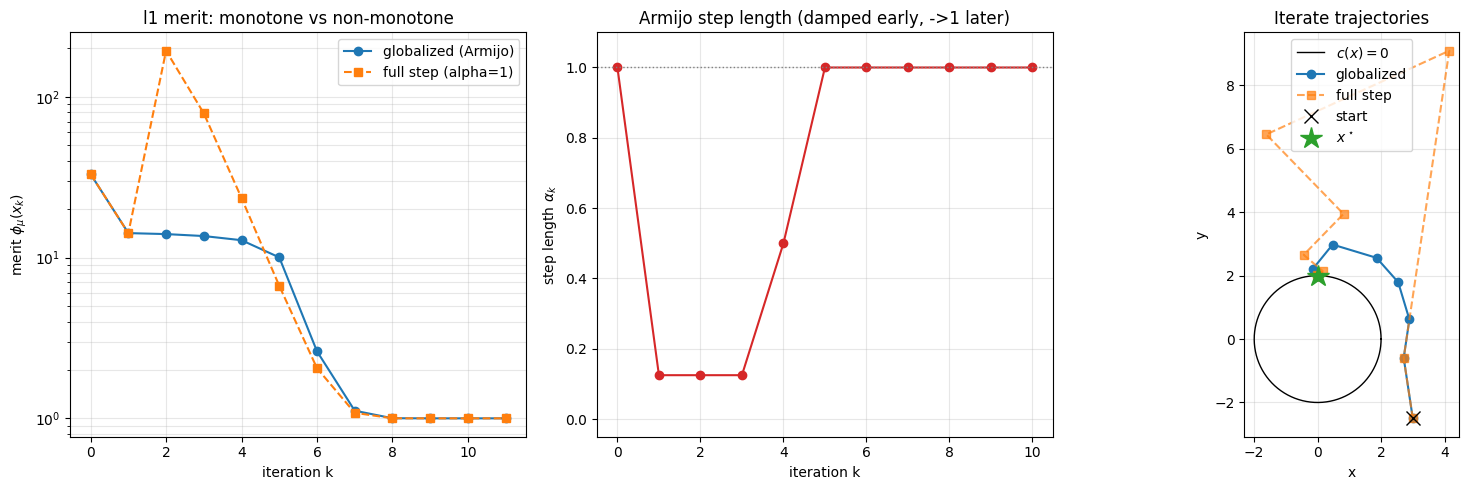

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# (1) 메리트 함수 비교 (단조 vs 비단조)
ax[0].plot(df_ls["k"],   df_ls["phi"],   "o-", label="globalized (Armijo)")
ax[0].plot(df_full["k"], df_full["phi"], "s--", label="full step (alpha=1)")
ax[0].set_xlabel("iteration k"); ax[0].set_ylabel(r"merit $\phi_\mu(x_k)$")
ax[0].set_title("l1 merit: monotone vs non-monotone")
ax[0].set_yscale("log")
ax[0].grid(True, which="both", alpha=0.3); ax[0].legend()

# (2) 스텝길이 alpha_k
ax[1].plot(df_ls["k"], df_ls["alpha"], "o-", color="C3")
ax[1].axhline(1.0, color="gray", ls=":", lw=1)
ax[1].set_xlabel("iteration k"); ax[1].set_ylabel(r"step length $\alpha_k$")
ax[1].set_title("Armijo step length (damped early, ->1 later)")
ax[1].set_ylim(-0.05, 1.1); ax[1].grid(True, alpha=0.3)

# (3) 궤적 비교
th = np.linspace(0, 2*np.pi, 400)
ax[2].plot(2*np.cos(th), 2*np.sin(th), "k-", lw=1, label=r"$c(x)=0$")
ax[2].plot(df_ls["x"],   df_ls["y"],   "o-", color="C0", label="globalized")
ax[2].plot(df_full["x"], df_full["y"], "s--", color="C1", alpha=0.7, label="full step")
ax[2].plot(3.0, -2.5, "kx", ms=10, label="start")
ax[2].plot(0, 2, "*", ms=16, color="C2", label=r"$x^\star$")
ax[2].set_xlabel("x"); ax[2].set_ylabel("y"); ax[2].set_aspect("equal")
ax[2].set_title("Iterate trajectories"); ax[2].grid(True, alpha=0.3); ax[2].legend()
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **메리트 단조감소 vs 폭주**: 전역화 SQP는 $\phi_\mu(x_k)$ 가 **단조 감소**한다(왼쪽 그래프 실선). 같은 출발점에서 단위 스텝(점선)은 메리트가 한 번 줄었다가 곧 **수백 배로 치솟으며 비단조**로 요동친다 — 표의 `full step` 열에서 $\phi$ 가 $33\!\to\!14\!\to\!193\!\to\cdots$ 처럼 폭주하는 것을 확인할 수 있다.
2. **스텝길이의 의미**: 초반에는 $\alpha_k<1$ 로 줄여 과도한 점프를 막고, 해에 가까워지면 $\alpha_k\to1$ 로 회복된다(가운데 그래프). "전역에서는 보수적으로, 국소에서는 빠른 뉴턴 스텝으로"라는 SQP 전역화의 핵심 거동이다.
3. **벌점 $\mu$ 의 역할**: $\mu\ge\|\lambda^{+}\|_\infty$ 를 유지해야 $d_k$ 가 $\phi_\mu$ 의 하강방향이 된다. $\mu$ 가 너무 작으면 제약위반을 충분히 벌하지 못해 직선탐색이 실패한다.
4. **왜 단위 스텝이 과도한가**: 정확 헤시안 $(2+2\lambda_k)I$ 가 해에서 멀 때 작게(또는 음수로) 추정되어 PD 안전장치 하한 $\tau$ 에 걸리면, QP가 곡률을 과소평가해 **뉴턴형 단위 스텝이 제약을 크게 넘긴다**. 일반적으로는 $\nabla^2_{xx}\mathcal{L}$ 수정(modification)이나 준뉴턴 근사(다음 문제)와 **반드시 직선탐색을 함께** 쓴다.

### 결론
> **순수 SQP는 국소법, 전역화가 실전법이다.** $\ell_1$ 정확 벌점 메리트 + Armijo 직선탐색은 먼 출발점에서도 **단조 감소**를 보장하며, 해 근방에서 스텝길이가 1로 회복되어 빠른 수렴을 되찾는다.

### 다음 문제 연결
- **CE 13.5.3**: 헤시안 $\nabla^2_{xx}\mathcal{L}$ 를 **직접 계산하지 않고** BFGS로 근사한다(2차 도함수 불필요). Powell 감쇠로 PD를 유지하고, **초선형 수렴**을 정확 헤시안의 2차 수렴과 비교한다.